<a href="https://colab.research.google.com/github/MMujtabaX/gini/blob/main/gini_entropy_information_gain_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Decision Trees — Gini, Entropy & Information Gain
### AtomCamp — Machine Learning Fundamentals

---

**What we'll cover:**
1. The dataset we'll use throughout
2. Gini Impurity — formula + worked example
3. Entropy — formula + worked example
4. Information Gain — which feature should we split on?
5. Visualising impurity
6. Verifying everything with sklearn

---
## 📦 0. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder

print("✅ Libraries loaded!")

✅ Libraries loaded!


---
## 📊 1. The Dataset — Will a Person Buy a Laptop?

We'll use this tiny dataset **throughout the entire notebook**.  
5 rows. 2 features. 1 target. Small enough to calculate everything by hand.

| # | Age   | Income | Buys Laptop? |
|---|-------|--------|---------------|
| 1 | Young | High   | Yes           |
| 2 | Young | Low    | No            |
| 3 | Old   | High   | Yes           |
| 4 | Old   | **Low**    | Yes           |
| 5 | Young | Low    | No            |

**Root node: 3 Yes, 2 No**

> ⚠️ **Common mistake to avoid — check the groups carefully:**
> - **High Income** → rows 1, 3 only → **2 rows** (NOT 3!)
> - **Low Income**  → rows 2, 4, 5  → **3 rows** (Row 4 is Old but LOW income!)
> - **Young**       → rows 1, 2, 5  → **3 rows**
> - **Old**         → rows 3, 4     → **2 rows**

In [ ]:
# Build the dataset
data = {
    'Row'   : [1,       2,       3,      4,      5],
    'Age'   : ['Young', 'Young', 'Old',  'Old',  'Young'],
    'Income': ['High',  'Low',   'High', 'Low',  'Low'],
    'Buys'  : ['Yes',   'No',    'Yes',  'Yes',  'No']
}
df = pd.DataFrame(data)
print(df.to_string(index=False))
print()

# Show the groups clearly
print("── Split by Income ──")
high = df[df['Income']=='High']
low  = df[df['Income']=='Low']
print(f"  High Income: rows {high['Row'].tolist()} → {(high['Buys']=='Yes').sum()} Yes, {(high['Buys']=='No').sum()} No")
print(f"  Low  Income: rows {low['Row'].tolist()}  → {(low['Buys']=='Yes').sum()} Yes, {(low['Buys']=='No').sum()} No")
print()
print("── Split by Age ──")
young = df[df['Age']=='Young']
old   = df[df['Age']=='Old']
print(f"  Young: rows {young['Row'].tolist()} → {(young['Buys']=='Yes').sum()} Yes, {(young['Buys']=='No').sum()} No")
print(f"  Old  : rows {old['Row'].tolist()}   → {(old['Buys']=='Yes').sum()} Yes, {(old['Buys']=='No').sum()} No")

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
 Row   Age Income Buys
   1 Young   High  Yes
   2 Young    Low   No
   3   Old   High  Yes
   4   Old    Low  Yes
   5 Young    Low   No

── Split by Income ──
  High Income: rows [1, 3] → 2 Yes, 0 No
  Low  Income: rows [2, 4, 5]  → 1 Yes, 2 No

── Split by Age ──
  Young: rows [1, 2, 5] → 1 Yes, 2 No
  Old  : rows [3, 4]   → 2 Yes, 0 No


c:\Users\HammadEzad\miniconda3\envs\atlas\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\HammadEzad\miniconda3\envs\atlas\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


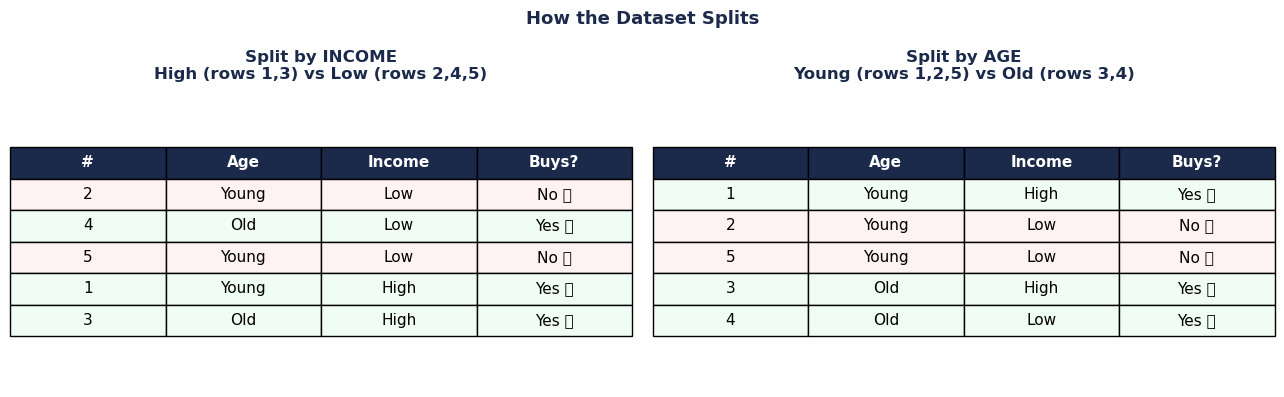

In [ ]:
# Visualise the groups side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('How the Dataset Splits', fontsize=13, fontweight='bold', color='#1B2A4A')

def draw_group_table(ax, title, rows_data):
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', color='#1B2A4A', pad=12)
    col_labels = ['#', 'Age', 'Income', 'Buys?']
    cell_colors = []
    for _, row in rows_data.iterrows():
        c = '#F0FDF4' if row['Buys'] == 'Yes' else '#FEF2F2'
        cell_colors.append([c]*4)
    table = ax.table(
        cellText=[[r['Row'], r['Age'], r['Income'],
                   'Yes ✅' if r['Buys']=='Yes' else 'No ❌']
                  for _, r in rows_data.iterrows()],
        colLabels=col_labels, cellLoc='center', loc='center',
        cellColours=cell_colors,
        colColours=['#1B2A4A']*4
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.4, 2.0)
    for j in range(4):
        table[0, j].set_text_props(color='white', fontweight='bold')

draw_group_table(axes[0], 'Split by INCOME\nHigh (rows 1,3) vs Low (rows 2,4,5)', df.sort_values('Income', ascending=False))
draw_group_table(axes[1], 'Split by AGE\nYoung (rows 1,2,5) vs Old (rows 3,4)', df.sort_values('Age', ascending=False))

plt.tight_layout()
plt.show()

---
## 📐 Concept 1 — Gini Impurity

> **Gini measures how "mixed up" a node is.**
> - Pure node → Gini = **0** &nbsp;&nbsp;&nbsp; Maximum confusion → Gini = **0.5**

$$\text{Gini} = 1 - \sum p_i^2$$

In [ ]:
# ── Root Node: 3 Yes, 2 No ──
p_yes = 3/5
p_no  = 2/5
gini_root = 1 - (p_yes**2 + p_no**2)

print("=" * 45)
print("  GINI — Root Node (3 Yes, 2 No)")
print("=" * 45)
print(f"  p(Yes) = 3/5 = {p_yes}")
print(f"  p(No)  = 2/5 = {p_no}")
print()
print(f"  Gini = 1 − (0.6² + 0.4²)")
print(f"       = 1 − ({p_yes**2:.2f} + {p_no**2:.2f})")
print(f"       = 1 − {p_yes**2 + p_no**2:.2f}")
print(f"       = {gini_root:.4f}  ← fairly impure")
print("=" * 45)

  GINI — Root Node (3 Yes, 2 No)
  p(Yes) = 3/5 = 0.6
  p(No)  = 2/5 = 0.4

  Gini = 1 − (0.6² + 0.4²)
       = 1 − (0.36 + 0.16)
       = 1 − 0.52
       = 0.4800  ← fairly impure


In [ ]:
# ── Split by Income ──
print("=" * 55)
print("  GINI — Split by Income")
print("=" * 55)

# HIGH Income: rows 1, 3  →  2 Yes, 0 No
gini_high = 1 - (1.0**2 + 0.0**2)
print(f"  HIGH Income (rows 1, 3) : 2 Yes, 0 No")
print(f"  p(Yes)=1.0  p(No)=0.0")
print(f"  Gini(High) = 1 − (1² + 0²) = {gini_high:.4f}  ← perfectly pure ✅")
print()

# LOW Income: rows 2, 4, 5  →  1 Yes, 2 No
p_yes_low = 1/3
p_no_low  = 2/3
gini_low  = 1 - (p_yes_low**2 + p_no_low**2)
print(f"  LOW Income (rows 2, 4, 5) : 1 Yes, 2 No")
print(f"  p(Yes) = 1/3 = {p_yes_low:.4f}")
print(f"  p(No)  = 2/3 = {p_no_low:.4f}")
print(f"  Gini(Low) = 1 − ((1/3)² + (2/3)²)")
print(f"            = 1 − ({p_yes_low**2:.4f} + {p_no_low**2:.4f})")
print(f"            = {gini_low:.4f}  ← still mixed")
print()

weighted_gini_income = (2/5)*gini_high + (3/5)*gini_low
print(f"  Weighted Gini = (2/5)×{gini_high:.4f} + (3/5)×{gini_low:.4f}")
print(f"                = 0 + {(3/5)*gini_low:.4f}")
print(f"                = {weighted_gini_income:.4f}")
print("=" * 55)

  GINI — Split by Income
  HIGH Income (rows 1, 3) : 2 Yes, 0 No
  p(Yes)=1.0  p(No)=0.0
  Gini(High) = 1 − (1² + 0²) = 0.0000  ← perfectly pure ✅

  LOW Income (rows 2, 4, 5) : 1 Yes, 2 No
  p(Yes) = 1/3 = 0.3333
  p(No)  = 2/3 = 0.6667
  Gini(Low) = 1 − ((1/3)² + (2/3)²)
            = 1 − (0.1111 + 0.4444)
            = 0.4444  ← still mixed

  Weighted Gini = (2/5)×0.0000 + (3/5)×0.4444
                = 0 + 0.2667
                = 0.2667


In [ ]:
# ── Split by Age ──
print("=" * 55)
print("  GINI — Split by Age")
print("=" * 55)

# Young: rows 1, 2, 5  →  1 Yes, 2 No
p_yes_young = 1/3
p_no_young  = 2/3
gini_young  = 1 - (p_yes_young**2 + p_no_young**2)
print(f"  YOUNG (rows 1, 2, 5) : 1 Yes, 2 No")
print(f"  p(Yes)=1/3={p_yes_young:.4f}  p(No)=2/3={p_no_young:.4f}")
print(f"  Gini(Young) = {gini_young:.4f}")
print()

# Old: rows 3, 4  →  2 Yes, 0 No
gini_old = 1 - (1.0**2 + 0.0**2)
print(f"  OLD (rows 3, 4) : 2 Yes, 0 No")
print(f"  p(Yes)=1.0  p(No)=0.0")
print(f"  Gini(Old) = {gini_old:.4f}  ← perfectly pure ✅")
print()

weighted_gini_age = (3/5)*gini_young + (2/5)*gini_old
print(f"  Weighted Gini = (3/5)×{gini_young:.4f} + (2/5)×{gini_old:.4f}")
print(f"                = {(3/5)*gini_young:.4f} + 0")
print(f"                = {weighted_gini_age:.4f}")
print("=" * 55)

print()
print(f"  🤝  Both splits give the same Gini: {weighted_gini_income:.4f}")
print("      The two features are perfectly correlated in this dataset.")

  GINI — Split by Age
  YOUNG (rows 1, 2, 5) : 1 Yes, 2 No
  p(Yes)=1/3=0.3333  p(No)=2/3=0.6667
  Gini(Young) = 0.4444

  OLD (rows 3, 4) : 2 Yes, 0 No
  p(Yes)=1.0  p(No)=0.0
  Gini(Old) = 0.0000  ← perfectly pure ✅

  Weighted Gini = (3/5)×0.4444 + (2/5)×0.0000
                = 0.2667 + 0
                = 0.2667

  🤝  Both splits give the same Gini: 0.2667
      The two features are perfectly correlated in this dataset.


---
## 🔥 Concept 2 — Entropy

$$\text{Entropy} = -\sum p_i \log_2(p_i)$$

**Quick tip:** $\log_2(0.5)=-1$ · $\log_2(0.25)=-2$ · $\log_2(1)=0$

In [ ]:
def entropy(yes, no):
    total = yes + no
    if total == 0: return 0
    p_yes = yes / total
    p_no  = no  / total
    h_yes = -p_yes * np.log2(p_yes) if p_yes > 0 else 0
    h_no  = -p_no  * np.log2(p_no)  if p_no  > 0 else 0
    return h_yes + h_no


# Root: 3 Yes, 2 No
entropy_root = entropy(3, 2)

print("=" * 55)
print("  ENTROPY — Root Node (3 Yes, 2 No)")
print("=" * 55)
print(f"  p(Yes)=0.6  p(No)=0.4")
print(f"  Entropy = −(0.6 × log₂(0.6)) − (0.4 × log₂(0.4))")
print(f"          = −(0.6 × {np.log2(0.6):.4f}) − (0.4 × {np.log2(0.4):.4f})")
print(f"          =  {-0.6*np.log2(0.6):.4f}  +  {-0.4*np.log2(0.4):.4f}")
print(f"          =  {entropy_root:.4f}  ← high disorder")
print("=" * 55)

  ENTROPY — Root Node (3 Yes, 2 No)
  p(Yes)=0.6  p(No)=0.4
  Entropy = −(0.6 × log₂(0.6)) − (0.4 × log₂(0.4))
          = −(0.6 × -0.7370) − (0.4 × -1.3219)
          =  0.4422  +  0.5288
          =  0.9710  ← high disorder


In [ ]:
# Entropy — split by Income
entropy_high = entropy(2, 0)   # rows 1,3 → 2 Yes, 0 No
entropy_low  = entropy(1, 2)   # rows 2,4,5 → 1 Yes, 2 No

print("=" * 58)
print("  ENTROPY — Split by Income")
print("=" * 58)
print(f"  HIGH (rows 1,3) : 2 Yes, 0 No → Entropy = {entropy_high:.4f}  ✅ pure")
print()
print(f"  LOW  (rows 2,4,5) : 1 Yes, 2 No")
print(f"  p(Yes)=1/3={1/3:.4f}  p(No)=2/3={2/3:.4f}")
print(f"  Entropy(Low) = −(1/3×log₂(1/3)) − (2/3×log₂(2/3))")
print(f"               = −({1/3:.4f}×{np.log2(1/3):.4f}) − ({2/3:.4f}×{np.log2(2/3):.4f})")
print(f"               =  {-1/3*np.log2(1/3):.4f} + {-2/3*np.log2(2/3):.4f}")
print(f"               =  {entropy_low:.4f}")
print()
weighted_entropy_income = (2/5)*entropy_high + (3/5)*entropy_low
print(f"  Weighted Entropy = (2/5)×{entropy_high:.4f} + (3/5)×{entropy_low:.4f}")
print(f"                   = 0 + {(3/5)*entropy_low:.4f}")
print(f"                   = {weighted_entropy_income:.4f}")
print("=" * 58)

  ENTROPY — Split by Income
  HIGH (rows 1,3) : 2 Yes, 0 No → Entropy = 0.0000  ✅ pure

  LOW  (rows 2,4,5) : 1 Yes, 2 No
  p(Yes)=1/3=0.3333  p(No)=2/3=0.6667
  Entropy(Low) = −(1/3×log₂(1/3)) − (2/3×log₂(2/3))
               = −(0.3333×-1.5850) − (0.6667×-0.5850)
               =  0.5283 + 0.3900
               =  0.9183

  Weighted Entropy = (2/5)×0.0000 + (3/5)×0.9183
                   = 0 + 0.5510
                   = 0.5510


In [ ]:
# Entropy — split by Age
entropy_young = entropy(1, 2)   # rows 1,2,5 → 1 Yes, 2 No
entropy_old   = entropy(2, 0)   # rows 3,4   → 2 Yes, 0 No

print("=" * 58)
print("  ENTROPY — Split by Age")
print("=" * 58)
print(f"  YOUNG (rows 1,2,5) : 1 Yes, 2 No → Entropy = {entropy_young:.4f}")
print(f"  (Same 1/3, 2/3 split as Low Income — gives the same entropy!)")
print()
print(f"  OLD   (rows 3,4)   : 2 Yes, 0 No → Entropy = {entropy_old:.4f}  ✅ pure")
print()
weighted_entropy_age = (3/5)*entropy_young + (2/5)*entropy_old
print(f"  Weighted Entropy = (3/5)×{entropy_young:.4f} + (2/5)×{entropy_old:.4f}")
print(f"                   = {(3/5)*entropy_young:.4f} + 0")
print(f"                   = {weighted_entropy_age:.4f}")
print("=" * 58)

  ENTROPY — Split by Age
  YOUNG (rows 1,2,5) : 1 Yes, 2 No → Entropy = 0.9183
  (Same 1/3, 2/3 split as Low Income — gives the same entropy!)

  OLD   (rows 3,4)   : 2 Yes, 0 No → Entropy = 0.0000  ✅ pure

  Weighted Entropy = (3/5)×0.9183 + (2/5)×0.0000
                   = 0.5510 + 0
                   = 0.5510


---
## 💡 Concept 3 — Information Gain

$$\text{IG} = \text{Entropy(Parent)} - \text{Weighted Entropy(Children)}$$

In [ ]:
IG_income = entropy_root - weighted_entropy_income
IG_age    = entropy_root - weighted_entropy_age

print("=" * 58)
print("  INFORMATION GAIN")
print("=" * 58)
print(f"  Parent Entropy (root)  : {entropy_root:.4f}")
print()
print(f"  IG(Income) = {entropy_root:.4f} − {weighted_entropy_income:.4f} = {IG_income:.4f}")
print(f"  IG(Age)    = {entropy_root:.4f} − {weighted_entropy_age:.4f} = {IG_age:.4f}")
print()
print(f"  🤝  TIED — both features give IG = {IG_income:.4f}")
print()
print("  Why? Look at the subgroup distributions:")
print("  Income High → 2 Yes, 0 No   =   Age Old   → 2 Yes, 0 No")
print("  Income Low  → 1 Yes, 2 No   =   Age Young → 1 Yes, 2 No")
print("  Mirror images! The features are perfectly correlated.")
print("  In a real dataset this almost never happens.")
print("=" * 58)

  INFORMATION GAIN
  Parent Entropy (root)  : 0.9710

  IG(Income) = 0.9710 − 0.5510 = 0.4200
  IG(Age)    = 0.9710 − 0.5510 = 0.4200

  🤝  TIED — both features give IG = 0.4200

  Why? Look at the subgroup distributions:
  Income High → 2 Yes, 0 No   =   Age Old   → 2 Yes, 0 No
  Income Low  → 1 Yes, 2 No   =   Age Young → 1 Yes, 2 No
  Mirror images! The features are perfectly correlated.
  In a real dataset this almost never happens.


---
## 📊 Visual Summary

C:\Users\HammadEzad\AppData\Local\Temp\ipykernel_50184\4018835228.py:48: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\HammadEzad\miniconda3\envs\atlas\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


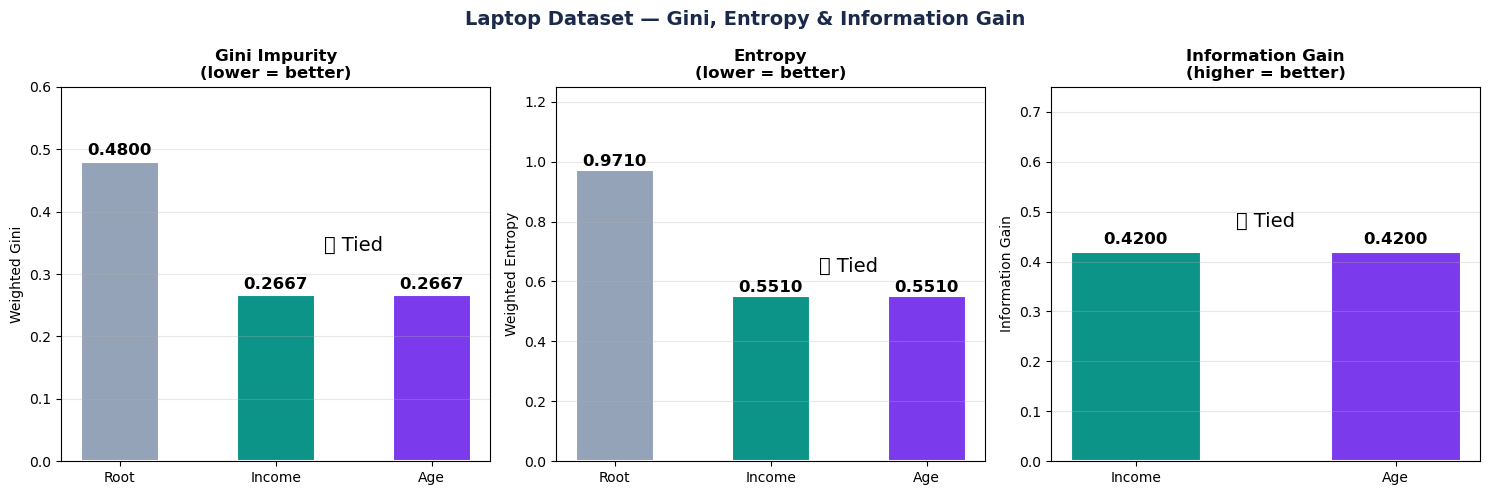

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Laptop Dataset — Gini, Entropy & Information Gain',
             fontsize=14, fontweight='bold', color='#1B2A4A')

COLORS = {'Root': '#94A3B8', 'Income': '#0D9488', 'Age': '#7C3AED'}
labels = ['Root', 'Income', 'Age']

# Gini
ax = axes[0]
vals = [gini_root, weighted_gini_income, weighted_gini_age]
bars = ax.bar(labels, vals, color=[COLORS[l] for l in labels], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.6)
ax.set_title('Gini Impurity\n(lower = better)', fontsize=12, fontweight='bold')
ax.set_ylabel('Weighted Gini')
ax.grid(True, axis='y', alpha=0.3)
ax.text(1.5, weighted_gini_income+0.07, '🤝 Tied', ha='center', fontsize=14)

# Entropy
ax = axes[1]
vals = [entropy_root, weighted_entropy_income, weighted_entropy_age]
bars = ax.bar(labels, vals, color=[COLORS[l] for l in labels], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.25)
ax.set_title('Entropy\n(lower = better)', fontsize=12, fontweight='bold')
ax.set_ylabel('Weighted Entropy')
ax.grid(True, axis='y', alpha=0.3)
ax.text(1.5, weighted_entropy_income+0.08, '🤝 Tied', ha='center', fontsize=14)

# Information Gain
ax = axes[2]
ig_vals = [IG_income, IG_age]
bars = ax.bar(['Income', 'Age'], ig_vals,
              color=[COLORS['Income'], COLORS['Age']], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, ig_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.75)
ax.set_title('Information Gain\n(higher = better)', fontsize=12, fontweight='bold')
ax.set_ylabel('Information Gain')
ax.grid(True, axis='y', alpha=0.3)
ax.text(0.5, IG_income+0.05, '🤝 Tied', ha='center', fontsize=14)

plt.tight_layout()
plt.show()

---
## 🔄 Gini vs Entropy Curve

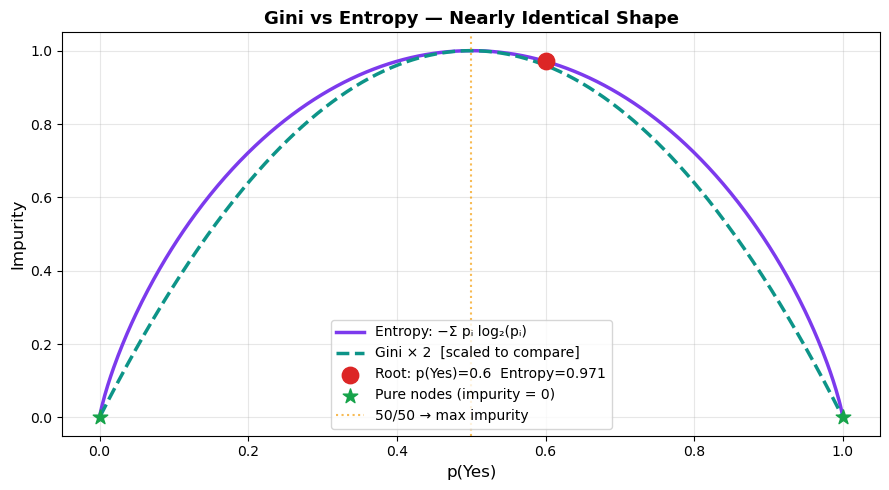


💡 Gini and Entropy track almost identically.
   In practice they almost always choose the same split.
   Gini is faster (no log). Entropy is rooted in information theory.
   sklearn default: criterion='gini'


In [ ]:
p = np.linspace(0.001, 0.999, 500)
gini_curve    = 1 - (p**2 + (1-p)**2)
entropy_curve = -(p*np.log2(p) + (1-p)*np.log2(1-p))

plt.figure(figsize=(9, 5))
plt.plot(p, entropy_curve, color='#7C3AED', linewidth=2.5, label='Entropy: −Σ pᵢ log₂(pᵢ)')
plt.plot(p, gini_curve*2,  color='#0D9488', linewidth=2.5, linestyle='--',
         label='Gini × 2  [scaled to compare]')

# Mark root node
plt.scatter([0.6], [entropy_root], color='#DC2626', s=140, zorder=5,
            label=f'Root: p(Yes)=0.6  Entropy={entropy_root:.3f}')
plt.scatter([0.0, 1.0], [0, 0], color='#16A34A', s=120, zorder=5,
            marker='*', label='Pure nodes (impurity = 0)')
plt.axvline(x=0.5, color='#F59E0B', linestyle=':', linewidth=1.5, alpha=0.7,
            label='50/50 → max impurity')

plt.xlabel('p(Yes)', fontsize=12)
plt.ylabel('Impurity', fontsize=12)
plt.title('Gini vs Entropy — Nearly Identical Shape', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Gini and Entropy track almost identically.")
print("   In practice they almost always choose the same split.")
print("   Gini is faster (no log). Entropy is rooted in information theory.")
print("   sklearn default: criterion='gini'")

---
## ✅ Verify With sklearn

In [ ]:
le = LabelEncoder()
df_enc = df.copy()
df_enc['Age']    = le.fit_transform(df['Age'])     # Old=0, Young=1
df_enc['Income'] = le.fit_transform(df['Income'])  # High=0, Low=1
df_enc['Buys']   = le.fit_transform(df['Buys'])    # No=0, Yes=1

X_sk = df_enc[['Age', 'Income']].values
y_sk = df_enc['Buys'].values

print("Encoded:")
print(df_enc[['Row','Age','Income','Buys']].to_string(index=False))
print("\n  Age: Old=0, Young=1  |  Income: High=0, Low=1  |  Buys: No=0, Yes=1")

Encoded:
 Row  Age  Income  Buys
   1    1       0     1
   2    1       1     0
   3    0       0     1
   4    0       1     1
   5    1       1     0

  Age: Old=0, Young=1  |  Income: High=0, Low=1  |  Buys: No=0, Yes=1


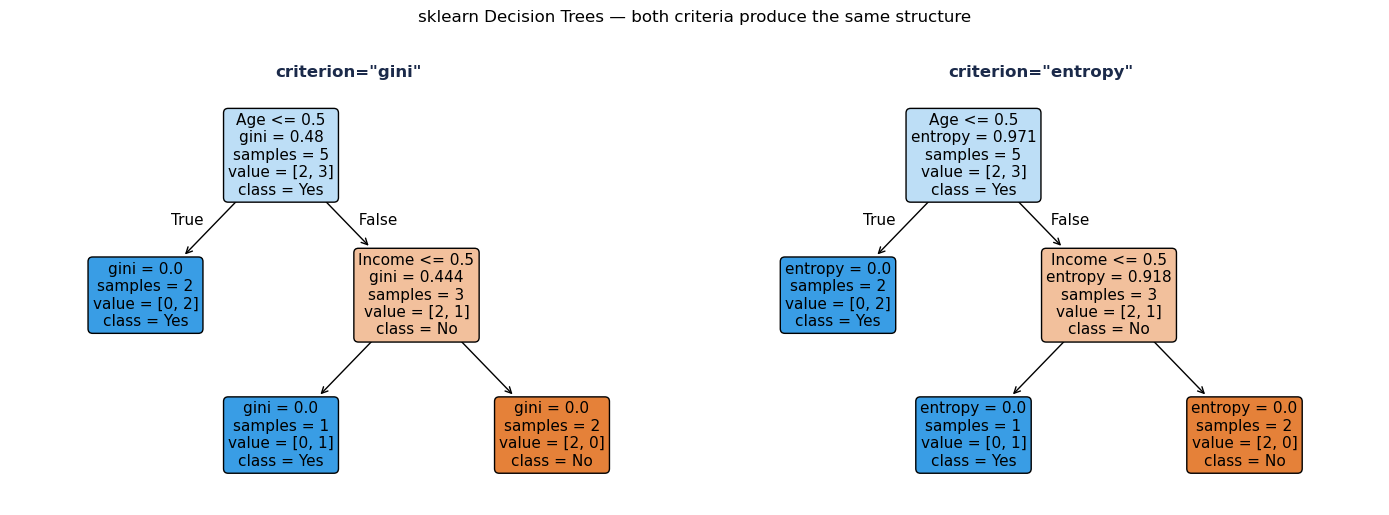

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, criterion in zip(axes, ['gini', 'entropy']):
    dt = DecisionTreeClassifier(criterion=criterion, random_state=42)
    dt.fit(X_sk, y_sk)
    plot_tree(dt, feature_names=['Age','Income'], class_names=['No','Yes'],
              filled=True, rounded=True, ax=ax, fontsize=11, impurity=True)
    ax.set_title(f'criterion="{criterion}"',
                 fontsize=12, fontweight='bold', color='#1B2A4A')

plt.suptitle('sklearn Decision Trees — both criteria produce the same structure',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 📋 Final Summary

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║       Gini, Entropy & Information Gain — Summary            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  CORRECT GROUPS (don't mix these up!):                       ║
║  High Income → rows 1, 3       (2 rows)                     ║
║  Low  Income → rows 2, 4, 5   (3 rows — row 4 is Old/Low!)  ║
║  Young       → rows 1, 2, 5   (3 rows)                      ║
║  Old         → rows 3, 4      (2 rows)                       ║
╠══════════════════════════════════════════════════════════════╣""")
print(f"║  Gini Root              : {gini_root:.4f}                          ║")
print(f"║  Weighted Gini(Income)  : {weighted_gini_income:.4f}  ← tied                   ║")
print(f"║  Weighted Gini(Age)     : {weighted_gini_age:.4f}  ← tied                   ║")
print(f"║                                                              ║")
print(f"║  Entropy Root           : {entropy_root:.4f}                          ║")
print(f"║  Weighted Entropy(Inc)  : {weighted_entropy_income:.4f}  ← tied                   ║")
print(f"║  Weighted Entropy(Age)  : {weighted_entropy_age:.4f}  ← tied                   ║")
print(f"║                                                              ║")
print(f"║  IG(Income)             : {IG_income:.4f}  ← tied                   ║")
print(f"║  IG(Age)                : {IG_age:.4f}  ← tied                   ║")
print("""
╠══════════════════════════════════════════════════════════════╣
║  🤝  Both features are equally good on this dataset          ║
║  because they are perfectly correlated: every Old person     ║
║  has High income, every Young has Low income (mostly).       ║
║  In real datasets this almost never happens.                 ║
╚══════════════════════════════════════════════════════════════╝
""")

---
## 🏋️ Practice Exercises

1. Add row `6 | Young | High | No`. Recalculate everything. Does the tie break now?

2. Add row `6 | Old | Low | No`. Which feature wins after this addition?

3. Prove to yourself: a node with **all Yes** → Gini=0 AND Entropy=0. Write both calculations by hand.

4. What is the maximum possible Gini for a binary classification problem? Why 0.5 and not 1.0?

5. **Challenge:** Add a 3rd feature `Student: Yes/No`. Assign your own values, calculate its IG, and compare against Income and Age.